<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 3 — Overfitting, Regularización y SVM</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporcionan dos datasets biomédicos independientes:

1. **EMG Gesture Classification** — features estadísticas de electromiografía de superficie (sEMG) registradas durante dos gestos activos de la mano. El dataset original tiene 3 clases (0=reposo, 1=pulgar abajo, 2=pulgar arriba); trabajaremos solo con **clases 1 y 2** — el problema clínicamente relevante: **¿el usuario intenta cerrar o abrir la mano?** Contexto: **control de prótesis mioeléctrica**.
2. **Brain Tumor MRI** — imágenes de resonancia magnética cerebral: **Tumor vs No tumor**. Pipeline: flatten → PCA → SVM.

---

### Datasets necesarios

| Datos | Fuente | Extensión |
|---|---|---|
| EMG Gesture Classification | [Kaggle](https://www.kaggle.com/datasets/birdy654/emg-gesture-classification-thumbs-up-and-down) | `.csv` |
| Brain Tumor MRI | [Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) | `.jpg` |

```
Clase4_Challenge/
├── Challenge3_ApellidoNombre.ipynb
├── emg_gestures.csv
└── brain_tumor/
    ├── Training/
    │   ├── notumor/
    │   └── tumor/   (glioma + meningioma + pituitary)
    └── Testing/
        ├── notumor/
        └── tumor/
```


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — Diagnóstico esperado

Responde antes de ver los datos:

1. La señal EMG de un músculo tiene patrones de amplitud y frecuencia distintos según el gesto. ¿Esperas que SVM Lineal o RBF funcione mejor para clasificar pulgar abajo vs pulgar arriba? ¿Por qué?
2. ¿Por qué es necesario PCA antes de SVM en imágenes MRI? ¿Qué pasaría si aplicaras SVM directamente sobre los 22 500 píxeles?
3. En una prótesis mioeléctrica, ¿qué error es más problemático: clasificar mal el gesto (FP) o no detectarlo (FN)? ¿Cambia la respuesta si lo comparas con el diagnóstico de tumor cerebral?

**📝 Tu respuesta (edita esta celda):**
1. Se espera que con un SVM RBF tenga una mejor precisión dado que es una clasificación EMG la cual tiene variaciones que una lineal no podría detectar o separar de forma tan simple como al colocar una frontera en un hiperplano 2D.
2. Las imágenes MRI tienen alta resolución, lo que hace el PCA es reducirlas a un vector de características; ayuda mucho para evitar el overfitting, el filtrado de ruido y por el hecho del esfuerzo que requiere el SVM para procesar una imagen tan grande. Si se aplicara sobre una imagen de 22500 pixeles (150x150), el tiempo de procesamiento se extiende y sería más propenso de tener overfitting.
3. Sería más problemático el clasificar mal el gesto ya que el problema se centra en el procesamiento al recoger la señal, cuando no se detecta involucra más al posicionamiento o conexión del sensor. En cambio, al diagnosticar un tumor cerebral, tiene más impacto no detectarlo, puesto en el contexto compromete más a la integridad del paciente conocer si existe alguna anomalia presente que localizarla en otro sitio.


### 1.2 — Pipeline completo

Completa el pipeline para cada dataset:

```
emg_gestures.csv
    │
    ▼
[ Paso A ] _______________  ← ¿Qué haces primero? (antes del split)
    │
    ▼
[ Paso B ] _______________  ← ¿Cuándo haces el split? ¿Por qué aquí?
    │
    ▼
[ Paso C ] _______________  ← ¿Qué preprocesamiento? ¿Con qué datos?
    │
    ▼
[ Paso D ] _______________  ← ¿Cómo eliges C sin tocar el test?
    │
    ▼
[ Paso E ] _______________  ← ¿Cuándo y cómo evalúas en test?

Brain Tumor MRI
    │
    ▼
[ Paso A ] flatten + _______________
    │
    ▼
[ Paso B ] _______________  ← ¿Por qué PCA aquí y no antes del split?
    │
    ▼
[ Paso C ] _______________
```

**📝 Tu respuesta (edita esta celda):**
- EMG: a. Carga y preparación  b. Split estratificado  c. Escalado con los datos de train  d. Barrido de C  e. Evaluación al final usando matriz de confusión
- MRI: a. flatten + StandarScaler b. PCA, para reducir la dimensionalidad de todo el conjunto de datos y no solo del train c. Entrenamiento de modelos


In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## Ejercicio 2 — Setup


In [ ]:
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GREEN = '#2E7D32'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, learning_curve,
                                      StratifiedKFold, cross_val_score)
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              recall_score, precision_score, f1_score)

plt.rcParams['figure.dpi'] = 120
BASE = Path('/content/drive/MyDrive/Challenges/Challenge_3')
print('Setup completo ✓')


Setup completo ✓


---
# PARTE 1 — Señal EMG: Control de Prótesis Mioeléctrica

## Ejercicio 3 — Carga, filtrado y EDA

El dataset contiene features estadísticas de sEMG con 3 clases originales:

| Clase | Gesto | Aplicación |
|---|---|---|
| 0 | Reposo (relax) | Estado neutro |
| 1 | Pulgar abajo | Apertura de mano |
| 2 | Pulgar arriba | Cierre de mano |

> Trabajamos con **clases 1 y 2** — el problema activo de la prótesis: ¿abrir o cerrar la mano?

### Paso 3.1 — Carga, inspección y filtrado


In [ ]:
df_raw = pd.read_csv(BASE / 'emg_gestures.csv')

print(f'Shape original: {df_raw.shape}')
print(f'\nDistribucion original de clases:')
TARGET = df_raw.columns[-1]
print(df_raw[TARGET].value_counts().sort_index())
df_raw.head()


Shape original: (3173, 2041)

Distribucion original de clases:
Label
0.0     965
1.0    1118
2.0    1090
Name: count, dtype: int64


,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_4,lag1_mean_5,lag1_mean_6,lag1_mean_7,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,...,freq_669_7,freq_679_7,freq_689_7,freq_699_7,freq_709_7,freq_720_7,freq_730_7,freq_740_7,freq_750_7,Label
0,-1.040000,-1.140000,-1.250000,-1.115000,-1.195000,-1.13000,-0.955000,-0.870000,-0.028839,-0.001432,...,0.021704,0.090170,0.054362,0.103776,0.045830,0.121577,0.040301,0.150245,0.106731,0.0
1,-1.050251,-1.040201,-1.110553,-3.713568,-0.693467,-0.81407,-1.095477,-1.030151,0.054493,0.400520,...,0.001214,0.001994,0.000601,0.002327,0.000819,0.001045,0.000895,0.001753,0.000857,0.0
2,-1.055000,-1.110000,-1.090000,-1.085000,-1.055000,-1.08500,-0.995000,-1.185000,1.613818,-0.138514,...,0.108152,0.095529,0.044617,0.105610,0.036643,0.071162,0.056146,0.079932,0.059948,2.0
3,-1.185000,-1.095000,-1.205000,-1.025000,-1.085000,-1.03500,-1.125000,-0.800000,0.518470,0.161348,...,0.065420,0.087290,0.063137,0.056442,0.112511,0.040761,0.087850,0.035891,0.210210,1.0
4,-1.135000,-1.235000,-1.150000,-1.030000,-1.105000,-1.16500,-1.175000,-1.115000,0.228686,0.274966,...,0.011784,0.068165,0.186553,0.064211,0.051568,0.036873,0.049948,0.061788,0.122097,1.0


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: filtra el dataframe conservando SOLO las filas donde TARGET == 1 o TARGET == 2
# Pista: usa isin()

df = df_raw[df_raw[TARGET].isin([1, 2])].copy()

# Recodificar: clase 1 → 0 (pulgar abajo), clase 2 → 1 (pulgar arriba)
# Esto convierte el problema a binario 0/1 para SVM
df = df.copy()
df[TARGET] = df[TARGET].map({1.0: 0, 2.0: 1})

print(f'Shape tras filtrado: {df.shape}')
print(f'\nClases tras recodificacion:')
print(df[TARGET].value_counts().sort_index())
print('  0 = Pulgar abajo  |  1 = Pulgar arriba')


Shape tras filtrado: (2208, 2041)

Clases tras recodificacion:
Label
0    1118
1    1090
Name: count, dtype: int64
  0 = Pulgar abajo  |  1 = Pulgar arriba


### Paso 3.2 — EDA: distribución de features por gesto
> ¿Qué features tienen distribuciones más distintas entre pulgar abajo y arriba? Esas serán las más discriminativas para SVM.


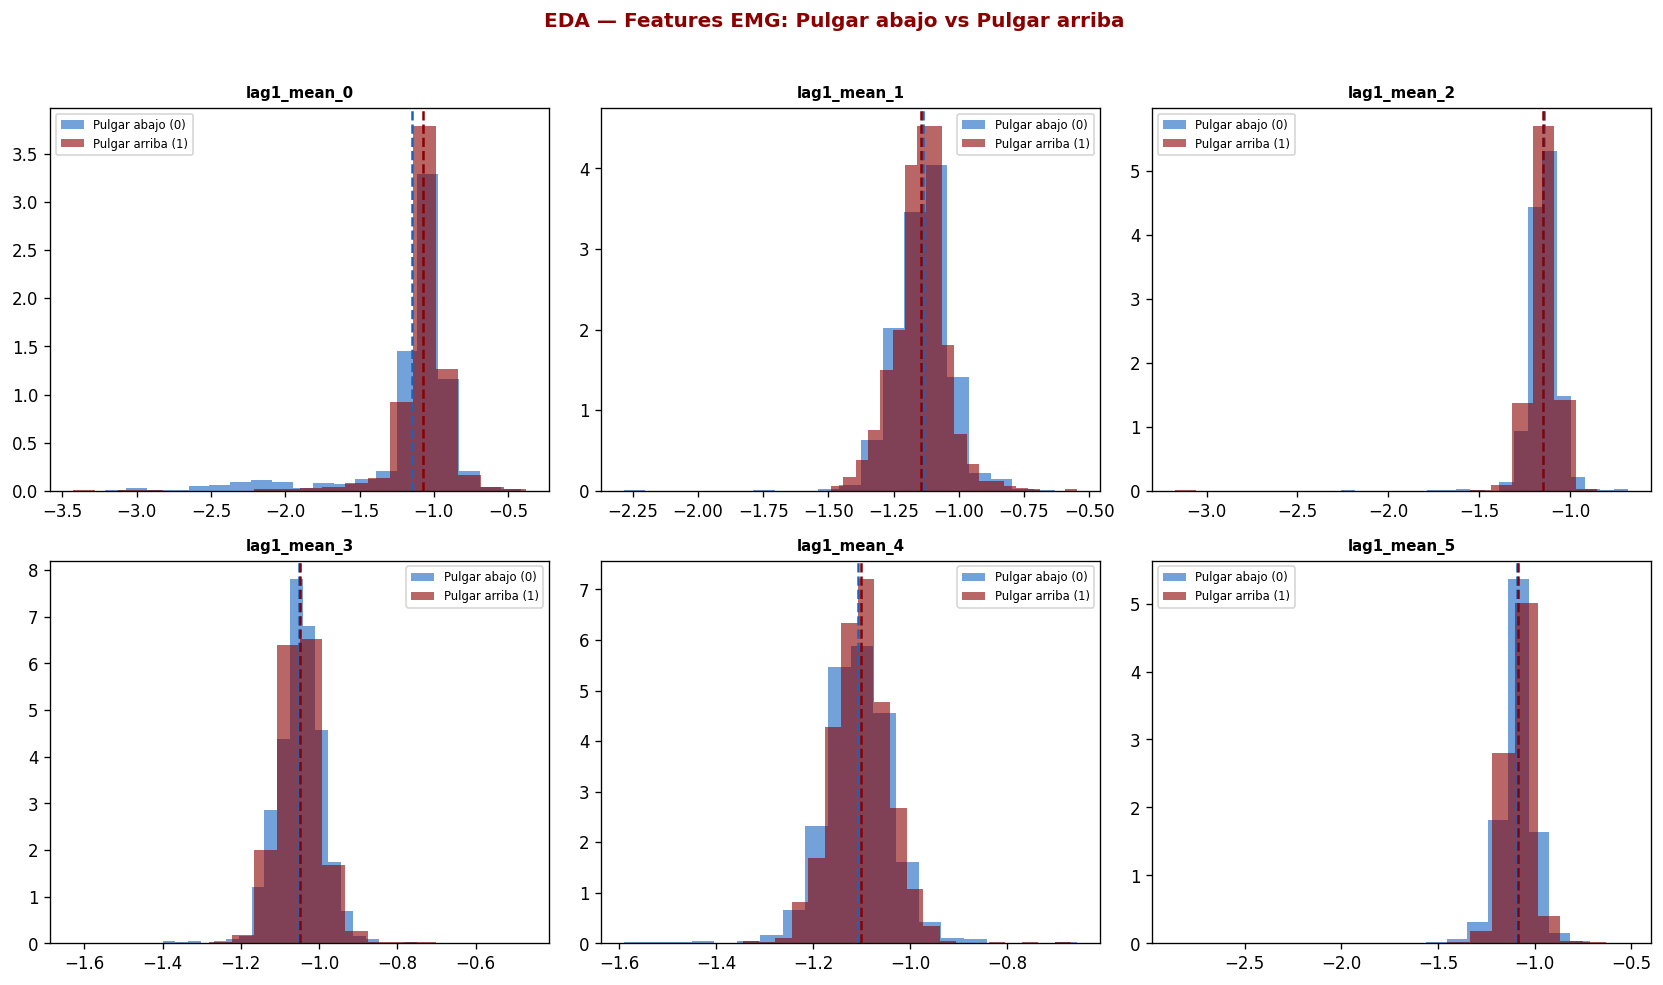

In [ ]:
features_num = df.drop(columns=[TARGET]).columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]
    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos por clase (density=True, alpha=0.6)
    # UPCH_BLUE para clase 0 (pulgar abajo), UPCH_RED para clase 1 (pulgar arriba)
    # Agrega líneas verticales con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'Pulgar abajo (0)'),
                                  (1, UPCH_RED,  'Pulgar arriba (1)')]:
        vals = df[df[TARGET]==clase][feat].values
        ax.hist(vals, bins=20, density=True, alpha=0.6, color=color, label=label)
        ax.axvline(vals.mean(), color=color, linestyle='--')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('EDA — Features EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('eda_emg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 4 — Preprocesamiento EMG

### Paso 4.1 — Split estratificado y escalado z-score

> **Regla:** separar primero, preprocesar después. El `StandardScaler` se ajusta **solo sobre train**.


In [ ]:
X_raw = df.drop(columns=[TARGET]).values
y_raw = df[TARGET].values.astype(int)   # 0 = pulgar abajo, 1 = pulgar arriba

# --- COMPLETA EL CÓDIGO ---
# TODO 1: split 80/20 estratificado, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

# TODO 2: StandardScaler — fit SOLO sobre train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  '
      f'Pulgar abajo: {(y_train==0).sum()}  Pulgar arriba: {(y_train==1).sum()}')
print(f'Test:  {X_test_sc.shape}   '
      f'Pulgar abajo: {(y_test==0).sum()}   Pulgar arriba: {(y_test==1).sum()}')
print(f'\nTrain escalado — mean~{X_train_sc.mean():.4f}  std~{X_train_sc.std():.4f}')


Train: (1766, 2040)  Pulgar abajo: 894  Pulgar arriba: 872
Test:  (442, 2040)   Pulgar abajo: 224   Pulgar arriba: 218

Train escalado — mean~0.0000  std~1.0000


---
## Ejercicio 5 — Curvas de aprendizaje

### Paso 5.1 — Diagnosticar overfitting

| Patrón | Diagnóstico | Solución |
|---|---|---|
| $E_{train} \approx E_{val}$ ambos altos | Underfitting | Más capacidad |
| $E_{train} \ll E_{val}$, brecha grande | Overfitting | Regularización, más datos |
| $E_{train} \approx E_{val}$ ambos bajos | Ajuste correcto | ✓ |


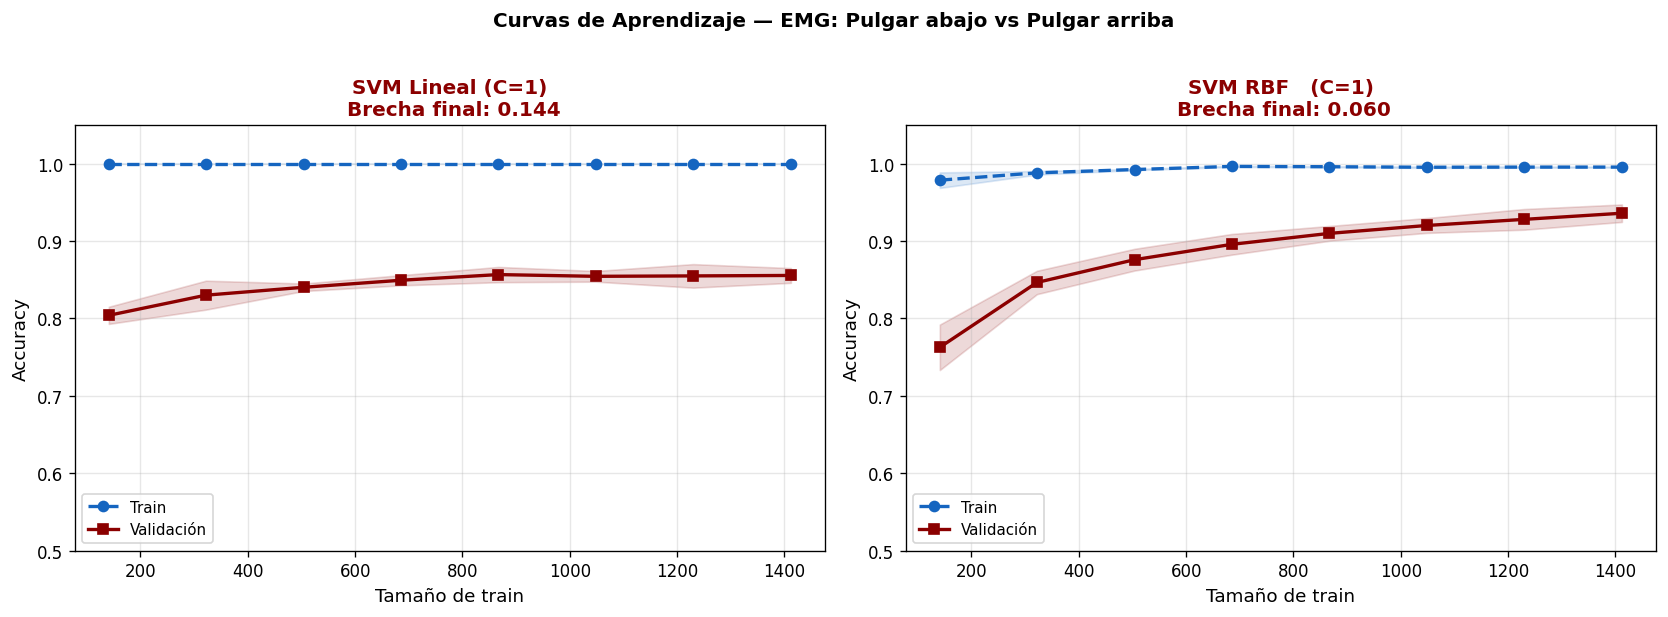

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

modelos = {
    'SVM Lineal (C=1)': SVC(kernel='linear', C=1, random_state=42),
    'SVM RBF   (C=1)':  SVC(kernel='rbf', C=1, gamma='scale', random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    # --- COMPLETA EL CÓDIGO ---
    # TODO: usa learning_curve() con cv=cv, scoring='accuracy', n_jobs=-1
    # Grafica train (UPCH_BLUE, 'o--') y val (UPCH_RED, 's-') con banda ±1std
    # Incluye la brecha final = tr_mean[-1] - val_mean[-1] en el título

    ts, tr_sc, val_sc = learning_curve(modelo, X_train_sc, y_train, train_sizes=train_sizes, cv=cv, scoring='accuracy', n_jobs=-1)
    tr_mean, tr_std = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    val_mean, val_std = val_sc.mean(axis=1), val_sc.std(axis=1)

    brecha_fin=float(tr_mean[-1] - val_mean[-1])

    ax.plot(ts, tr_mean, color=UPCH_BLUE, linewidth=2, linestyle='--', marker='o', label='Train')
    ax.fill_between(ts, tr_mean+tr_std, tr_mean-tr_std, alpha=0.15, color=UPCH_BLUE)
    ax.plot(ts, val_mean, color=UPCH_RED,  linewidth=2, linestyle='-',  marker='s', label='Validación')
    ax.fill_between(ts, val_mean+val_std, val_mean-val_std, alpha=0.15, color=UPCH_RED)
    ax.set_xlabel('Tamaño de train', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{nombre}\n Brecha final: {brecha_fin:.3f}', fontsize=12, fontweight='bold', color=UPCH_RED)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


plt.suptitle('Curvas de Aprendizaje — EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 5.2 — Interpreta las curvas

1. ¿Qué modelo tiene mayor brecha $\Delta_{gen}$? ¿Hay overfitting?
2. ¿Agregar más registros EMG mejoraría el modelo? ¿Cómo lo sabes mirando la curva?
3. ¿Qué kernel elegirías para una prótesis en tiempo real? Considera también la velocidad de predicción.

**📝 Tu respuesta:**
1. El modelo es el que tiene de brecha final 0.144. Podríamos decir que sí hay overfitting puesto que el accuracy es de 1 y la data testeada tiene mayor error con el mismo modelo.
2. Probablemente no mejoraría el primer modelo lineal puesto que por el comportamiento de la gráfica, el aprendizaje ha llegado a una meseta.
3. Considerando la velocidad de predicción para una prótesis que será usada en tiempo real, el modelo más eficiente respecto al tiempo es el lineal. Sin embargo, es importante recordar que tiene más error en la data testada

---
## Ejercicio 6 — Selección de C con CV-5

### Paso 6.1 — Barrido de C en escala logarítmica

> **Anti-leakage:** el barrido se realiza **solo sobre train**. El test set no se toca hasta el paso final.

$$\min_{w,b,\xi} \;\frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i$$


In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10]
acc_lineal, acc_rbf = [], []

# --- COMPLETA EL CÓDIGO ---
# TODO: para cada C entrena SVM Lineal y RBF con cross_val_score
# cv=cv, scoring='accuracy' — guarda el promedio de 5 folds
# imprime los resultados por cada C

for C in C_values:
    svm_lin = SVC(kernel='linear', C=C, random_state=42)
    svm_rbf = SVC(kernel='rbf',    C=C, gamma='scale', random_state=42)

    sc_lin  = cross_val_score(svm_lin, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    sc_rbf  = cross_val_score(svm_rbf, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()

    acc_lineal.append(sc_lin)
    acc_rbf.append(sc_rbf)
    print(f'C={C:>6}   Lineal: {sc_lin:.4f}   RBF: {sc_rbf:.4f}')

C_opt_lin = C_values[int(np.argmax(acc_lineal))]
C_opt_rbf = C_values[int(np.argmax(acc_rbf))]
print(f'\nC optimo Lineal: {C_opt_lin}  (CV acc = {max(acc_lineal):.4f})')
print(f'C optimo RBF:    {C_opt_rbf}  (CV acc = {max(acc_rbf):.4f})')


C= 0.001   Lineal: 0.8901   RBF: 0.5062
C=  0.01   Lineal: 0.8562   RBF: 0.5062
C=   0.1   Lineal: 0.8562   RBF: 0.7389
C=     1   Lineal: 0.8562   RBF: 0.9360
C=    10   Lineal: 0.8562   RBF: 0.9485

C optimo Lineal: 0.001  (CV acc = 0.8901)
C optimo RBF:    10  (CV acc = 0.9485)


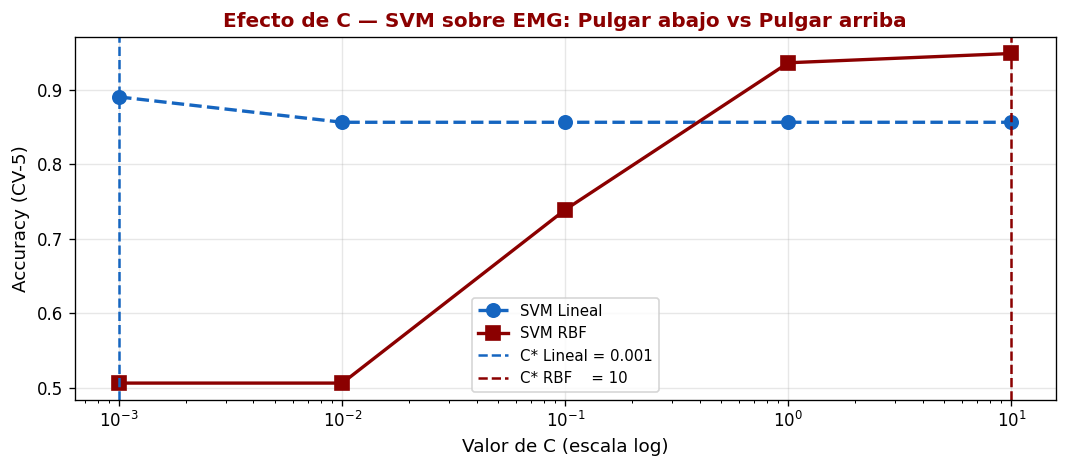

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica acc_lineal y acc_rbf vs C_values en escala log
# UPCH_BLUE para Lineal, UPCH_RED para RBF
# Incluye líneas verticales en C_opt_lin y C_opt_rbf

fig, ax = plt.subplots(figsize=(9, 4))

ax.semilogx(C_values, acc_lineal, color=UPCH_BLUE, linestyle='--', marker='o', linewidth=2, markersize=8, label='SVM Lineal')
ax.semilogx(C_values, acc_rbf,  color=UPCH_RED, linestyle='-', marker='s', linewidth=2, markersize=8, label='SVM RBF')
ax.axvline(C_opt_lin, color=UPCH_BLUE, linestyle='--', label=f'C* Lineal = {C_opt_lin}')
ax.axvline(C_opt_rbf, color=UPCH_RED,  linestyle='--', label=f'C* RBF    = {C_opt_rbf}')

ax.set_xlabel('Valor de C (escala log)', fontsize=11)
ax.set_ylabel('Accuracy (CV-5)', fontsize=11)
ax.set_title('Efecto de C — SVM sobre EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('barrido_C_emg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 7 — Evaluación final EMG

### Paso 7.1 — Test set (una sola vez)

> Usa los C óptimos ya seleccionados. **No ajustes nada más después de ver el test.**


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena SVM Lineal (C_opt_lin) y RBF (C_opt_rbf) sobre X_train_sc
svm_lin_final = SVC(kernel='linear', C=C_opt_lin, random_state=42)
svm_rbf_final = SVC(kernel='rbf', C=C_opt_rbf, random_state=42)

svm_lin_final.fit(X_train_sc, y_train) # fit lineal
svm_rbf_final.fit(X_train_sc, y_train) # fit rbf

# TODO 2: predice sobre X_test_sc
y_pred_lin = svm_lin_final.predict(X_test_sc)
y_pred_rbf = svm_rbf_final.predict(X_test_sc)


acc_lin = accuracy_score(y_test, y_pred_lin)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print('=' * 60)
print('    EVALUACION FINAL — SVM sobre EMG Gestos')
print('=' * 60)
print(f'{"Modelo":<20} {"C*":<8} {"Accuracy":<12} {"SVs"}')
print('-' * 60)
print(f'{"SVM Lineal":<20} {C_opt_lin:<8} {acc_lin:.4f}       '
      f'{svm_lin_final.n_support_.sum()}')
print(f'{"SVM RBF":<20} {C_opt_rbf:<8} {acc_rbf:.4f}       '
      f'{svm_rbf_final.n_support_.sum()}')


    EVALUACION FINAL — SVM sobre EMG Gestos
Modelo               C*       Accuracy     SVs
------------------------------------------------------------
SVM Lineal           0.001    0.8869       933
SVM RBF              10       0.9525       1312


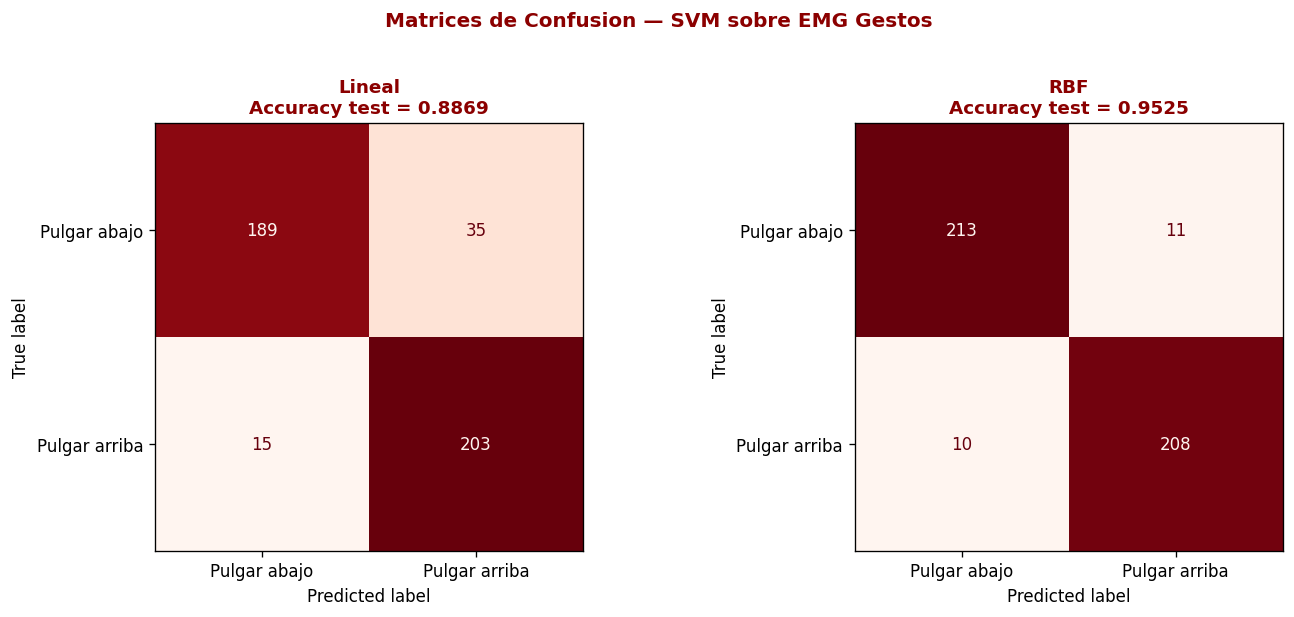

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: matrices de confusion lado a lado
# display_labels=['Pulgar abajo', 'Pulgar arriba'], cmap='Reds'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nombre, y_pred, acc in zip(axes, ['Lineal', 'RBF'], [y_pred_lin, y_pred_rbf], [acc_lin, acc_rbf]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pulgar abajo', 'Pulgar arriba']).plot(ax=ax, cmap='Reds', colorbar=False)
    ax.set_title(f'{nombre}\nAccuracy test = {acc:.4f}', fontsize=11, fontweight='bold', color=UPCH_RED)

plt.suptitle('Matrices de Confusion — SVM sobre EMG Gestos',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('cm_svm_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 7.2 — Métricas clínicas


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa accuracy, recall, precision, F1 para ambos modelos
# Clase positiva = 1 (pulgar arriba)

print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 65)
for nombre, y_pred in [('SVM Lineal', y_pred_lin), ('SVM RBF', y_pred_rbf)]:
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f'{nombre:<20} {acc:.4f}       {rec:.4f}       {prec:.4f}      {f1:.4f}')
    print('-' * 65)
    print(classification_report(y_test, y_pred, target_names=['Pulgar abajo', 'Pulgar arriba']))

print()
print('→ Para una protesis en tiempo real: ¿accuracy o velocidad de prediccion?')
print('  SVM Lineal predice en O(d), SVM RBF predice en O(N_sv x d).')
print('  Si la diferencia de accuracy es <2%, ¿cuál elegirías? ¿Por qué?')
print()
##########
print('📝 Tu respuesta: Si la diferencia fuese menor al 2%, escogeríamos el modelo lineal ya que tiene una velocidad de predicción más rápida')
##########


Modelo               Accuracy     Recall       Precision    F1
-----------------------------------------------------------------
SVM Lineal           0.8869       0.9312       0.8529      0.8904
-----------------------------------------------------------------
               precision    recall  f1-score   support

 Pulgar abajo       0.93      0.84      0.88       224
Pulgar arriba       0.85      0.93      0.89       218

     accuracy                           0.89       442
    macro avg       0.89      0.89      0.89       442
 weighted avg       0.89      0.89      0.89       442

SVM RBF              0.9525       0.9541       0.9498      0.9519
-----------------------------------------------------------------
               precision    recall  f1-score   support

 Pulgar abajo       0.96      0.95      0.95       224
Pulgar arriba       0.95      0.95      0.95       218

     accuracy                           0.95       442
    macro avg       0.95      0.95      0.95       4

---
# PARTE 2 — Imagen MRI: Tumor Cerebral

## Ejercicio 8 — Carga y preprocesamiento

El dataset **Brain Tumor MRI** contiene imágenes de resonancia magnética:
- **notumor** → cerebro sano (clase 0)
- **tumor** → glioma, meningioma o tumor pituitario agrupados (clase 1)

Pipeline:
$$I \in \mathbb{R}^{150 \times 150} \xrightarrow{\text{flatten}} x \in \mathbb{R}^{22500} \xrightarrow{\text{PCA}} z \in \mathbb{R}^{d} \xrightarrow{\text{SVM-RBF}} \hat{y}$$

### Paso 8.1 — Carga de imágenes


In [62]:
DATA_DIR = BASE / 'brain_tumor'

def cargar_brain_mri(split='Training', max_por_clase=120, target_size=(150, 150)):
    """
    Carga imagenes Brain Tumor MRI en escala de grises y normaliza a [0,1].
    Clases: notumor=0, tumor=1 (glioma+meningioma+pituitary agrupados).

    Parametros:
        split         : 'Training' | 'Testing'
        max_por_clase : limite de imagenes por clase
        target_size   : (H, W) para resize

    Retorna:
        imgs   : array (N, H, W) float32 en [0,1]
        labels : array de enteros (0=notumor, 1=tumor)
    """
    imgs, labels = [], []
    ruta_sano = DATA_DIR / split / 'notumor'
    for ruta in (list(ruta_sano.glob('*.jpg'))+
                 list(ruta_sano.glob('*.jpeg')))[:max_por_clase]:
        img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
            labels.append(0)

    tumor_base_path = DATA_DIR / split / 'tumor'
    if tumor_base_path.exists():
        all_tumor_files = []
        for tipo in ['glioma', 'meningioma', 'pituitary']:
            ruta_tipo = tumor_base_path / tipo
            if ruta_tipo.exists():
                all_tumor_files.extend(list(ruta_tipo.glob('*.jpg')) + list(ruta_tipo.glob('*.jpeg')))

        for ruta in all_tumor_files[:max_por_clase]:
            img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
                labels.append(1)

    return np.array(imgs), np.array(labels)

imgs_train, y_img_train = cargar_brain_mri('Training',  max_por_clase=120)
imgs_test,  y_img_test  = cargar_brain_mri('Testing',   max_por_clase=40)
print(f'Train: {imgs_train.shape}  '
      f'NoTumor: {(y_img_train==0).sum()}  Tumor: {(y_img_train==1).sum()}')
print(f'Test:  {imgs_test.shape}   '
      f'NoTumor: {(y_img_test==0).sum()}   Tumor: {(y_img_test==1).sum()}')

Train: (240, 150, 150)  NoTumor: 120  Tumor: 120
Test:  (80, 150, 150)   NoTumor: 40   Tumor: 40


### Paso 8.2 — EDA: visualizar ejemplos
> ¿Qué diferencias morfológicas observas entre cerebro con tumor y sin tumor?


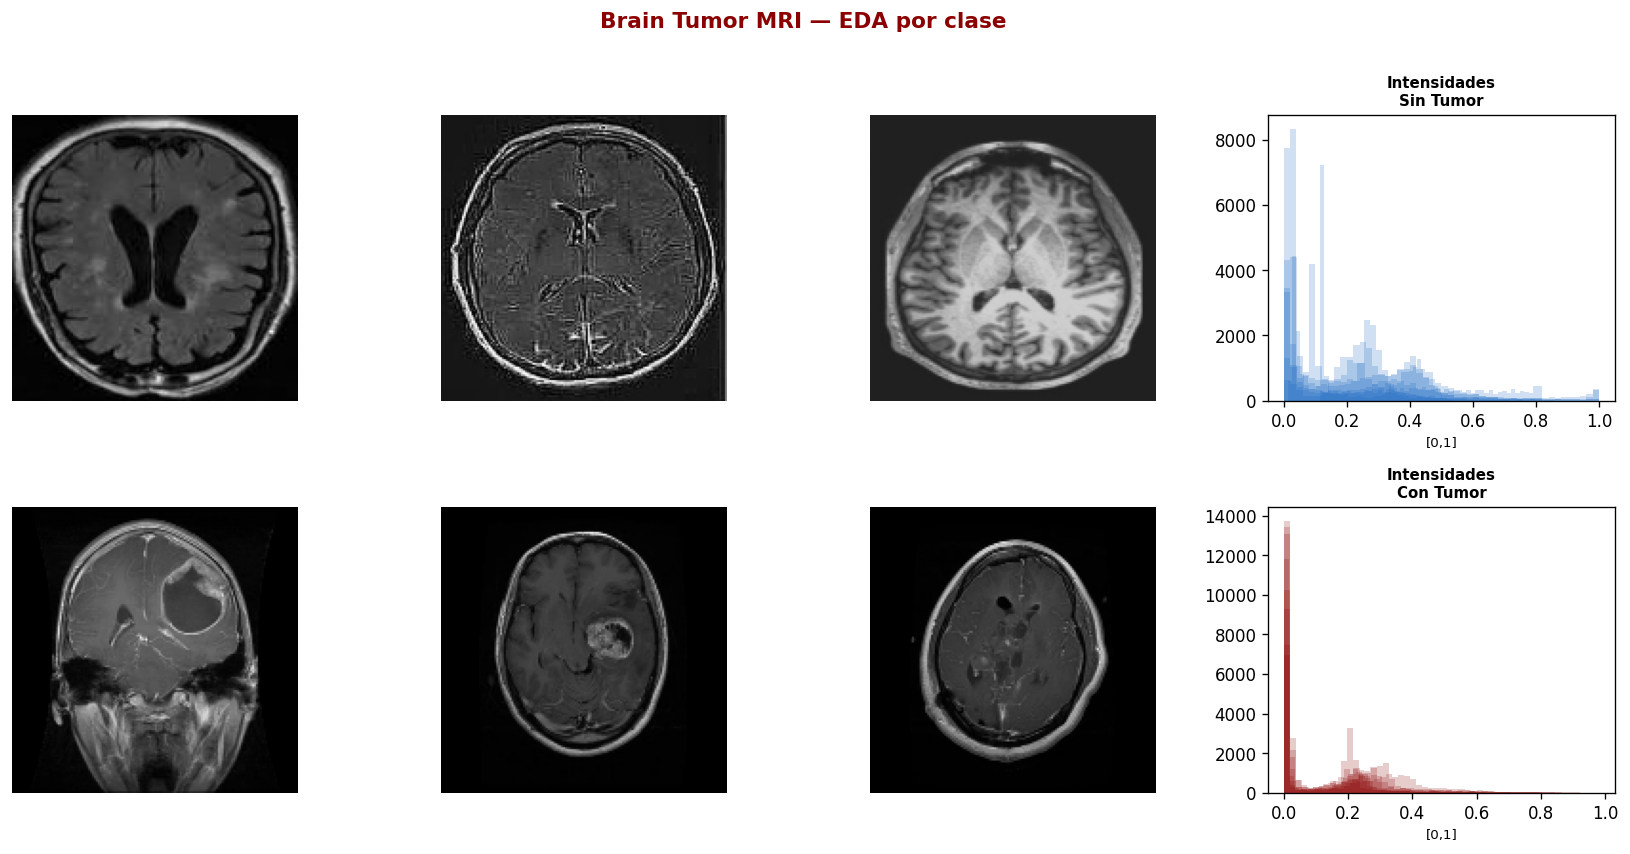

In [63]:
import matplotlib.pyplot as plt

UPCH_BLUE  = '#1565C0'
UPCH_RED   = '#8B0000'

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, (clase_str, clase_id, color) in enumerate([
    ('Sin Tumor', 0, UPCH_BLUE),
    ('Con Tumor', 1, UPCH_RED)
]):
    idx_c = np.where(y_img_train == clase_id)[0]
    for col in range(3):
        ax = axes[row, col]
        ax.imshow(imgs_train[idx_c[col]], cmap='gray', vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(clase_str, fontsize=11, fontweight='bold', color=color)
        ax.axis('off')
    ax_h = axes[row, 3]
    for i in idx_c[:8]:
        ax_h.hist(imgs_train[i].flatten(), bins=50, alpha=0.2, color=color)

    ax_h.set_title(f'Intensidades\n{clase_str}', fontsize=9, fontweight='bold')
    ax_h.set_xlabel('[0,1]', fontsize=8)
plt.suptitle('Brain Tumor MRI — EDA por clase',
             fontsize=13, fontweight='bold', color=UPCH_RED, y=1.01)
plt.tight_layout()
plt.savefig('eda_brain_mri.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 9 — PCA sobre MRI cerebral

### Paso 9.1 — Flatten + StandardScaler + varianza explicada

> **Anti-leakage:** `StandardScaler` y `PCA` se ajustan **solo sobre train**. En la realidad clínica, cuando llega una nueva imagen, se proyecta con el scaler y PCA aprendidos del train — nunca se recalculan.


Flatten — Train: (240, 22500)   Test: (80, 22500)


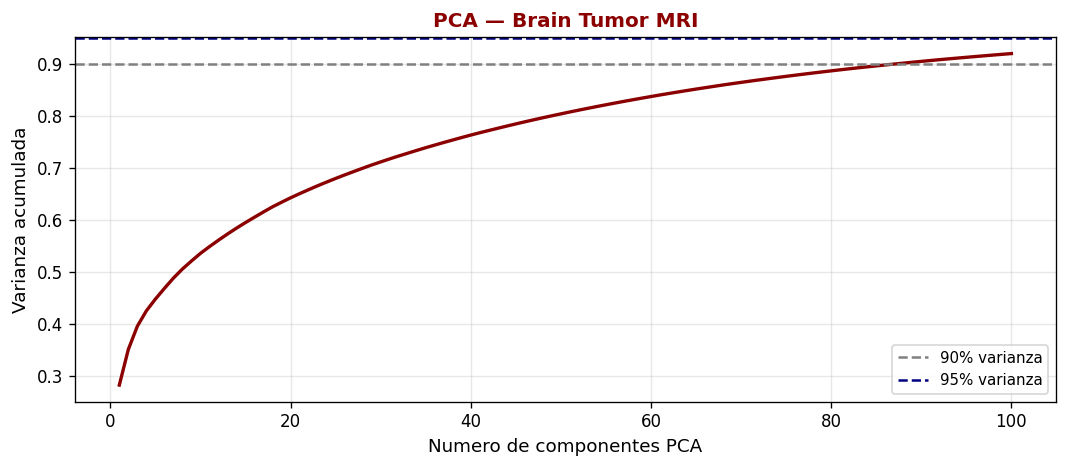

In [64]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: flatten las imágenes (reshape a 2D)
X_flat_train = imgs_train.reshape(len(imgs_train),-1)   # shape esperada: (N_train, 22500)
X_flat_test  = imgs_test.reshape(len(imgs_test),-1)   # shape esperada: (N_test,  22500)
print(f'Flatten — Train: {X_flat_train.shape}   Test: {X_flat_test.shape}')

# TODO 2: StandardScaler — fit SOLO sobre train
scaler_mri = StandardScaler()
X_sc_train = scaler_mri.fit_transform(X_flat_train)
X_sc_test  = scaler_mri.transform(X_flat_test)


# Varianza explicada
pca_exp = PCA(n_components=100, random_state=42)
pca_exp.fit(X_sc_train)
var_acum = np.cumsum(pca_exp.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 101), var_acum, color=UPCH_RED, lw=2)
ax.axhline(0.90, color='gray', ls='--', lw=1.5, label='90% varianza')
ax.axhline(0.95, color='navy', ls='--', lw=1.5, label='95% varianza')
ax.set_xlabel('Numero de componentes PCA', fontsize=11)
ax.set_ylabel('Varianza acumulada', fontsize=11)
ax.set_title('PCA — Brain Tumor MRI',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_varianza_mri.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
# --- COMPLETA EL CÓDIGO ---
# TODO: ajusta PCA con N_COMP=80, transforma train y test
N_COMP = 80
pca    = PCA(n_components=N_COMP, random_state=42)
Z_train = pca.fit_transform(X_sc_train)   # fit_transform SOLO sobre X_sc_train
Z_test  = pca.transform(X_sc_test)   # transform sobre X_sc_test (no fit)

print(f'Reduccion: {X_sc_train.shape[1]:,} → {N_COMP} features '
      f'({pca.explained_variance_ratio_.sum():.1%} varianza conservada)')


Reduccion: 22,500 → 80 features (88.7% varianza conservada)


---
## Ejercicio 10 — SVM-RBF sobre MRI cerebral

### Paso 10.1 — Selección de C con CV-5

$$K(z_i, z_j) = \exp\left(-\gamma \|z_i - z_j\|^2\right)$$


In [66]:
C_values_mri = [0.01, 0.1, 1, 10]
cv_mri = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- COMPLETA EL CÓDIGO ---
# TODO: barrido de C para SVM-RBF sobre Z_train, y_img_train
# imprime el resultado por cada C
acc_cv_mri = []
for C in C_values_mri:
    svm_mri = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    sc = cross_val_score(svm_mri, Z_train, y_img_train, cv=cv_mri, scoring='accuracy').mean() # Corrected cv=cv_img to cv=cv_mri
    acc_cv_mri.append(sc) # Corrected acc_cv_img to acc_cv_mri
    print(f'C={C:>6}   CV accuracy = {sc:.4f}')

C_opt_mri = C_values_mri[int(np.argmax(acc_cv_mri))] # Corrected acc_cv_img to acc_cv_mri
print(f'\nC optimo MRI: {C_opt_mri}  (CV acc = {max(acc_cv_mri):.4f})') # Corrected acc_cv_img to acc_cv_mri

C=  0.01   CV accuracy = 0.8708
C=   0.1   CV accuracy = 0.8833
C=     1   CV accuracy = 0.9333
C=    10   CV accuracy = 0.9375

C optimo MRI: 10  (CV acc = 0.9375)


SVM-RBF Brain MRI (C=10) — Accuracy test: 0.9000

              precision    recall  f1-score   support

   Sin Tumor       0.86      0.95      0.90        40
   Con Tumor       0.94      0.85      0.89        40

    accuracy                           0.90        80
   macro avg       0.90      0.90      0.90        80
weighted avg       0.90      0.90      0.90        80



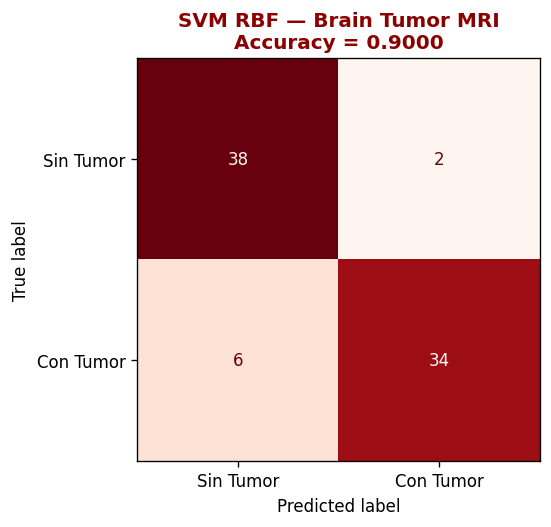

In [67]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena modelo final, predice en test, matriz de confusion
svm_mri_final = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)
svm_mri_final.fit(Z_train, y_img_train)
y_pred_mri = svm_mri_final.predict(Z_test)
acc_mri    = accuracy_score(y_img_test, y_pred_mri)


print(f'SVM-RBF Brain MRI (C={C_opt_mri}) — Accuracy test: {acc_mri:.4f}')
print()
print(classification_report(y_img_test, y_pred_mri,
                             target_names=['Sin Tumor', 'Con Tumor']))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_img_test, y_pred_mri),
    display_labels=['Sin Tumor', 'Con Tumor']
).plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title(f'SVM RBF — Brain Tumor MRI\nAccuracy = {acc_mri:.4f}',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('cm_svm_mri.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 11 — Curva de aprendizaje MRI
### ¿Necesitamos más imágenes?


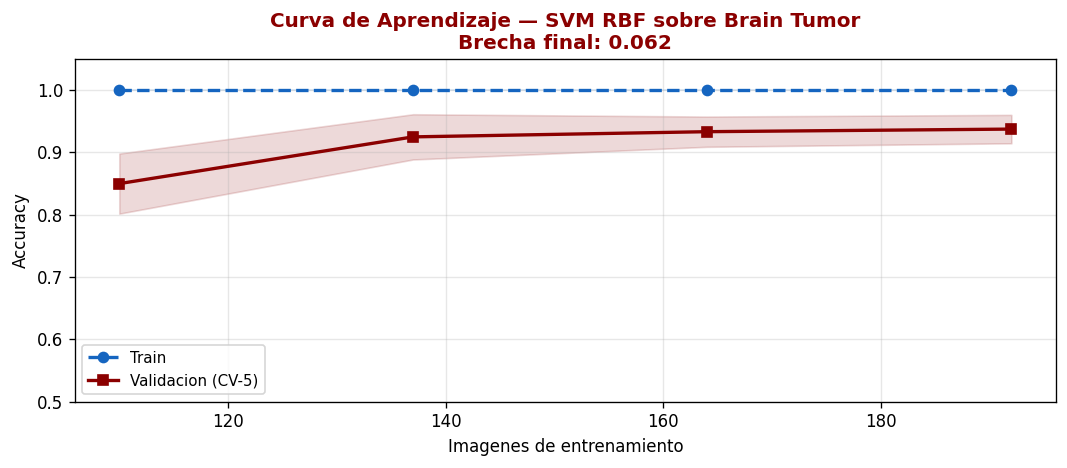

In [68]:
# --- COMPLETA EL CÓDIGO ---
# TODO: curva de aprendizaje SVM-RBF con C_opt_mri sobre Z_train
# train_sizes = np.linspace(0.15, 1.0, 7)
# Grafica train (UPCH_BLUE) y val (UPCH_RED) con banda ±1std
# Incluye la brecha final en el título

train_sizes_mri = np.linspace(0.15, 1.0, 7)
svm_lc_mri = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)
ts_mri, tr_mri, val_mri = learning_curve(svm_lc_mri, Z_train, y_img_train, train_sizes=train_sizes_mri,
                                         cv=cv_mri, scoring='accuracy', n_jobs=-1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ts_mri, tr_mri.mean(axis=1),  linestyle= '--', marker='o', color=UPCH_BLUE, linewidth=2, label='Train')
ax.fill_between(ts_mri, tr_mri.mean(axis=1)-tr_mri.std(axis=1),
                tr_mri.mean(axis=1)+tr_mri.std(axis=1), alpha=0.15, color=UPCH_BLUE)
ax.plot(ts_mri, val_mri.mean(axis=1), linestyle= '-', marker='s', color=UPCH_RED, linewidth=2, label='Validacion (CV-5)')
ax.fill_between(ts_mri, val_mri.mean(axis=1)-val_mri.std(axis=1),
                val_mri.mean(axis=1)+val_mri.std(axis=1), alpha=0.15, color=UPCH_RED)
brecha_mri = float(tr_mri.mean(axis=1)[-1] - val_mri.mean(axis=1)[-1])
ax.set_title(f'Curva de Aprendizaje — SVM RBF sobre Brain Tumor\nBrecha final: {brecha_mri:.3f}',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.set_xlabel('Imagenes de entrenamiento', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('curva_aprendizaje_mri.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreta la curva

1. ¿La curva de validación sigue subiendo? → ¿Más imágenes MRI ayudarían?
2. Compara la brecha de MRI con la brecha de EMG. ¿Por qué son distintas?
3. ¿Qué limitación tiene SVM+PCA para imágenes médicas que CNN no tiene?

**📝 Tu respuesta:**
1. Sí, a pesar de la poca cantidad de imágenes para el modelo, la curva sigue subiendo. Más imágenes en el entrenamiento ayudarían a generalizar y mejorar el accuracy en el testeo.
2. Ambas muestran diferencias sutiles en el perfomance que se evidenciado en la brecha que en EMG es 0.060 y en MRI es 0.062. El accuracy en el MRI tiene una velocidad de mejora más rápida y cuenta con menos datos de entrenamiento en comparación de EMG cabe resaltar que esto puede ser explicado porque se trata en EMG de señales y en MRI de imágenes
3. SVM+PCA requiere aplanar la imagen por lo que su precisión es limitada ante variaciones de forma o posición. En contraste, las CNN mantienen la forma entre píxeles y aprenden automáticamente a detectar patrones.

---
## Ejercicio 12 — Análisis final comparativo
### Paso 12.1 — Tabla de métricas


In [69]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa — usa el mejor modelo de EMG

print('=' * 70)
print('         RESUMEN FINAL — Challenge 3')
print('=' * 70)
print(f'{"Dataset":<20} {"Modelo":<15} '
      f'{"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 70)
# EMG — mejor modelo
print(f'{"EMG":<20} {nombre:<15} '
      f'{acc:<12.4f} {rec:<12.4f} {prec:<12.4f} {f1:.4f}')
# Brain MRI
print(f'{"Brain MRI":<20} {"SVM RBF":<15} '
      f'{accuracy_score(y_img_test, y_pred_mri):<12.4f} {recall_score(y_img_test, y_pred_mri,pos_label=1):<12.4f} {precision_score(y_img_test, y_pred_mri, pos_label=1):<12.4f} {f1_score(y_img_test, y_pred_mri,pos_label=1):.4f}')



         RESUMEN FINAL — Challenge 3
Dataset              Modelo          Accuracy     Recall       Precision    F1
----------------------------------------------------------------------
EMG                  SVM RBF         0.9525       0.9541       0.9498       0.9519
Brain MRI            SVM RBF         0.9000       0.8500       0.9444       0.8947


### Paso 12.2 — Reflexión clínica final

Completa la tabla:

| Escenario | Dataset | Modelo | Métrica prioritaria | Justificación |
|---|---|---|---|---|
| Prótesis mioeléctrica tiempo real | EMG | SVM Lineal | Velocidad de predicción | Para la prótesis es necesario tener un resultado correcto en la mayoría de casos y una velocidad rápida de respuesta|
| Screening tumor cerebral | MRI | SVM RBF | Recall | Al tener uso médico, es crucial tener un número alto de verdaderos positivos en comparación con el grupo de detectados como verdaderos |
| Sistema embebido de bajo consumo | EMG | SVM RBF | F1-score | Principalmente se debe dar prioridad a la precisión y el recall para asegurar una correcta clasificación|

**📝 Tu respuesta:** ___


---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge3_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 5
</div>
